## `Filtrage` 

__`Conclusion les limites d'utilisation des filtres Non-local means`__
1. Textures et détails à faible contraste
2. Patches contrastés mais rares
3. Bruit non gaussien
4. Temps de calcul
5. __`Choix des paramètres`__


__`Filtre local`__ : 
 - pour chaque pixel $i$, on moyenne les valeurs bruitées $v(j)$ des pixels $j$ dans le voisinage de $i$ ou $\hat u(i) =  \sum_j v(j)$
__`Non-local`__ : 
- tous les pixels $j$ sont utilisés pour le débruitage, le poids qui reflète la similarité de gris entre $j$ et $i$ ou $\hat u(i)= \sum_{j}w_{ij}v(j)$
- le poids depend de la di-similarity entre $i$ et $j$:

Non‑Local Means proposé par Buades`
- c'est un algorithme précis de débruitage qui pour chaque pixel $i$, 
- regarde des patchs autour de tous les autres pixels $j$ (dans toute l’image ou une grande fenêtre),
- on calcule une distance entre les patchs (descripteurs) d($H_i ,H_j$).
- le débruitage Non-Local Means est une méthode de débruitage par patchs 
- il exploite la redondance des motifs dans l’image, même à grande distance.

__`on construit des poids non locaux`__ : $\omega(i,j)\alpha*\exp \Bigl(-\frac{d(H_i,H_j)}{−h_2} \Bigr)$
__`la valeur filtrée est une moyenne pondérée :`__ $\hat u(i)= \sum_{j}w_{ij}u(j)$
Ce notebook implémente le filtrage Non-Local-Mean avec descripteurs ACP :
- Construire la matrice de patches ACP des patches → descripteurs H de dim d=15
- Distance PCA-NL-Means : $D(i,j)= \frac{1}{(2w+1)^2} ||H_i − H_j||^2$
- Kernel : $K(i,j)=exp(− \frac{D(i,j)}{2\tau^2})$ normalisé
- Formule générale du filtrage non-locale (moyenne pondérée) : $\hat f(i)=\sum_j K(i,j)⋅f(j)$

__`Idée de base:`__
- une image naturelle contient beaucoup de motifs qui se répètent (textures, briques, feuillage, etc.),
- pas seulement localement mais partout dans l’image.
- pour débruiter un pixel $i$, NLM ne se limite pas à un petit voisinage local,
- il cherche, dans une zone plus large ou toute l’image, des patchs similaires au patch centré en $i$.
- la valeur débruitée de $i$ est une moyenne pondérée des valeurs d’autres pixels $j$, 
- où le poids est d’autant plus grand que le patch autour de $j$ ressemble à celui de $i$.
__`Calcul des poids:`__
- on considère un patch $P_i$ de taille $(2w+1)×(2w+1)$ autour du pixel $i$.
- pour chaque pixel $j$ dans une fenêtre de recherche autour de $i$, on compare $P_i$ et $P_j$
- on regarde tous les pixels $j$ dans une fenêtre de recherche autour de $i$ (ie: un carré de rayon $W$).
- ​le poids est souvent de la forme: 
$$\omega(i,j)\alpha\exp \Bigl( \large \frac{||P_i − P_j||_2^2}{−h_2} \Bigr)$$
__`Donc:`__ 
   - $P_i$ : vecteur ou bloc 2D représentant l’intensité autour de i.
   - $P_j$ : même chose autour de j.
   - $\omega(i,j)$ : devient grand si $P_j$ ressemble beaucoup à $P_i$ , petit sinon.
   - $h$  : contrôle la décroissance (plus h est grand, plus on accepte des patchs différents).
   - $\alpha$  : est un facteur de normalisation souvent choisi pour que $\sum_j \omega(i,j)=1$.
__`Formule typique`__: 

- Ensuite, le pixel débruité en $i$ est une moyenne pondérée des pixels $j$, avec ces poids :
$$ \hat{u}(i) = \sum_{j} w(i,j)\, v(j), \qquad \sum_{j} w(i,j) = 1 $$
- où $v$ est l’image bruitée et $w(i,j)$ dépend de la distance entre les patchs autour de $i$ et $j$.   

In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

#from __future__ import division
from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

### `Patches in Images`
Cette partie est dédiée à l'étude des structures de patch dans les images 
Dimension de l'image $N = n \times n$.

In [2]:
n = 128
x, y = 100, 200 
print(f"[{y-n}:{y+n},{x-n}:{x+n}]")

[72:328,-28:228]


- Nous chargeons un image bruitée $f_0\in \mathcal{R}^N$.
- En Python l’indexation d’une image se fait en ligne, colonne = y, x.
- Les coordonnées x,y représente le centre du patch que l'on extrait dans l’image f.
  - y-n:y+n coupe verticalement (lignes).
  - x-n:x+n coupe horizontalement (colonnes).

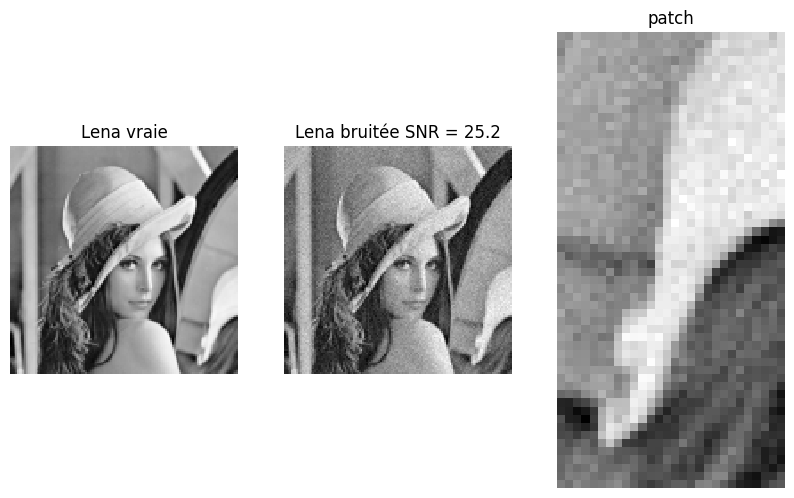

In [3]:
from skimage.transform import rescale, resize
from skimage.util import crop

path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/lena.png'

sigma = .03

img = load_image(name, n)
imgtrue = img.astype(float).copy()
noised = imgtrue + np.random.randn(n, n) * sigma
imgnoised = noised.copy()

f0 = imgnoised[y-n:y+n, x-n:x+n].copy()
# équivalent conceptuel d'un rescale des valeurs dans [0,1]
plt.figure(figsize=(10, 10))
imageplot(clamp(imgtrue),'Lena vraie',[1,3,1])
imageplot(clamp(imgnoised),f'Lena bruitée SNR = {snr(imgtrue,imgnoised):.3g}',[1,3,2])
imageplot(clamp(f0),'patch',[1,3,3])

Ajouter un bruit gaussien additif $\epsilon$, tel que l'image bruitée $f=f_0+\epsilon$ où $\epsilon \approx \mathcal{N}(0,\sigma^2\text{Id}_N)$.
$\epsilon$ est un vecteur aléatoire gaussien de dimension $N$ (où $N$ est le nombre de pixels), de   
- moyenne nulle (centre en 0),  
- de matrice de covariance $\mathcal{N}(0,\sigma^2\text{Id}_N)$
Chaque pixel de bruit suit une loi normale $\mathcal{N}(0,\sigma^2)$, les composantes sont indépendantes entre elles.


Nous construisons les coordonnées des patchs $7×7$ car $w=3$, donc $w_1 = 2 * w + 1 = 7$ autour de chaque pixel, en gérant les bords par réflexion. 
Nous construisons des matrices de tailles $(n,n,w_1,w_1)$ pour indexer les position de X et Y du pixel à extraire. 
- Localisation des pixels.
- Décalage (offsets)
- Localisation des pixels à extraire

In [4]:
w = 3

__Pour $w=3$, se réfère à un patch carré centré sur un pixel__.
- $w$ est la demi‑largeur, 
- $w$ demi‑hauteur du patch, 
- la distance en pixels entre le centre et chaque bord.
__La largeur totale du patch est $w1=2w+1$__
- Avec w=3, on a $w_1=2×3+1=7$.
`Concrètement, si le centre est au (x,y), le patch couvre` :
- horizontalement : $(x−3)$ , $(x−2)$ , $(x−1)$ , `(x)` , $(x+1)$ , $(x+2)$ , $(x+3)$ → 7 colonnes,
- verticalement   : $(y−3)$ , $(y−2)$ , $(y−1)$ , `(y)` , $(y+1)$ , $(y+2)$ , $(y+3)$ → 7 lignes.
Donc le patch est un carré de taille $7×7$ centré sur ce pixel.
- Xmesh, Ymesh (centres)

In [5]:
import numpy as np

def patch_coords_grid(n,w):
    # Paramètres et grilles de base
    Ymesh, Xmesh = np.meshgrid(np.arange(n), np.arange(n),indexing='ij')
    # Décalages dans le patch on crée les offsets du patch :
    dYmesh, dXmesh = np.meshgrid(np.arange(-w,w+1),np.arange(-w,w+1))
    dX = dXmesh[None, None, :, :]    
    dY = dYmesh[None, None, :, :] 
    X = Xmesh[:, :, None, None] + dX
    Y = Ymesh[:, :, None, None] + dY   
    return X, Y

#### __`Traiter les conditions limites des bords par réflexion`__ 
- pour traiter les bords de l’image lorsqu'un patch se trouve à l'extérieur, 
- on prolonge l’image, les pixels en dehors sont pris comme un miroir de ceux à l’intérieur.
__Pour une réflexion symétrique__
Sur $[0, n-1]$, le schéma typique 1D est pour le padding miroir parmi d'autres est :
- Pour un index brut k, le ramener dans [0, n-1] en appliquant un modulo sur une période $2*(n-1)$ 
- puis une réflexion autour des bords.

In [6]:
def reflect_indices(idx, n):
    # idx : tableau (X ou Y), n : taille (128 pour une image 128x128)
    if n == 1:
        return np.zeros_like(idx)
    period = 2*(n-1)
    idx_mod = idx % period
    mask = idx_mod >= n
    idx_mod[mask] = period - idx_mod[mask]
    return idx_mod

__`Operateur d'extracteur de patch`__
- vectorisation de l’image transforme l'image 2D en vecteur 1D, lisant les pixels colonne par colonne. 
- cette vectorisation est requise car compute_patches utilise une indexation linéaire 1D pour extraire les patches.

In [7]:
# img : image 2D (n, n)
n = imgnoised.shape[0]
print(f"imgnoised.shape:{imgnoised.shape}\nimg:{imgnoised[0:1,:3]}")
# transforme ton image 2D en un vecteur 1D, en lisant les pixels colonne par colonne.
imgnoised_reshp = img.T.reshape(-1)   # ou img.reshape(-1, order='F')
print(f"imgnoised_reshp.shape : {imgnoised_reshp.shape} , {imgnoised_reshp[:3]}")

imgnoised.shape:(128, 128)
img:[[0.66188922 0.67306976 0.64337494]]
imgnoised_reshp.shape : (16384,) , [0.671896   0.66605115 0.65288794]


__`L'idée centrale : image → vecteur 1D`__
 - l'image n×n est aplatie en vecteur 1D (f_vec de taille $n^2$ ). 
 - pour accéder au pixel de coordonnées (x=ligne, y=colonne), 
 - l'indice linéaire correspondant dans ce vecteur est : $ind(x,y)=y + x⋅n_{col}$ 

Pour une image vectorisée colonne par colonne, 
 - l’indice linéaire d’un pixel $(x,y)$ (où $x$ = colonne, $y$ = ligne)
 - ind = $ Y_{ref}  + X_{ref}* n$ sert à transformer les coordonnées 2D $(Y_{ref}, X_{ref})$ en indices 1D dans le vecteur $f_{vec}$.

`Définir la matrice du patch`: 
 - $P$ de taille $(n,n,w_1,w_1)$ 
 - chaque $|P(i,j,:,:)|$ représente un patch $(w_1,w_1)$ extrait autour du pixel $(i,j)$ dans l'image.

In [8]:
def compute_reflect_grid(f_vec,n,X,Y):
#    print(f"f_vec : {np.array(f_vec).shape}, X : {np.array(X).shape} ")
    X_ref = reflect_indices(X, n)
    Y_ref = reflect_indices(Y, n)
    ind = Y_ref + X_ref * n # même shape que X, Y
    return f_vec[ind]   # renvoie les patchs

# On calcule tous les patchs une fois pour toutes
X,Y = patch_coords_grid(n,w)
matrxofpatch = compute_reflect_grid(imgnoised_reshp,n,X,Y) # P est un ndarray, shape (n, n, w1, w1)
print(f"La dimension de matrxofpatch : {matrxofpatch.shape}\ndécrit un tenseur 4D qui code un patch 7×7 autour de chaque pixel d’une image 128×128")

La dimension de matrxofpatch : (128, 128, 7, 7)
décrit un tenseur 4D qui code un patch 7×7 autour de chaque pixel d’une image 128×128


`Afficher différents exemples de patchs`

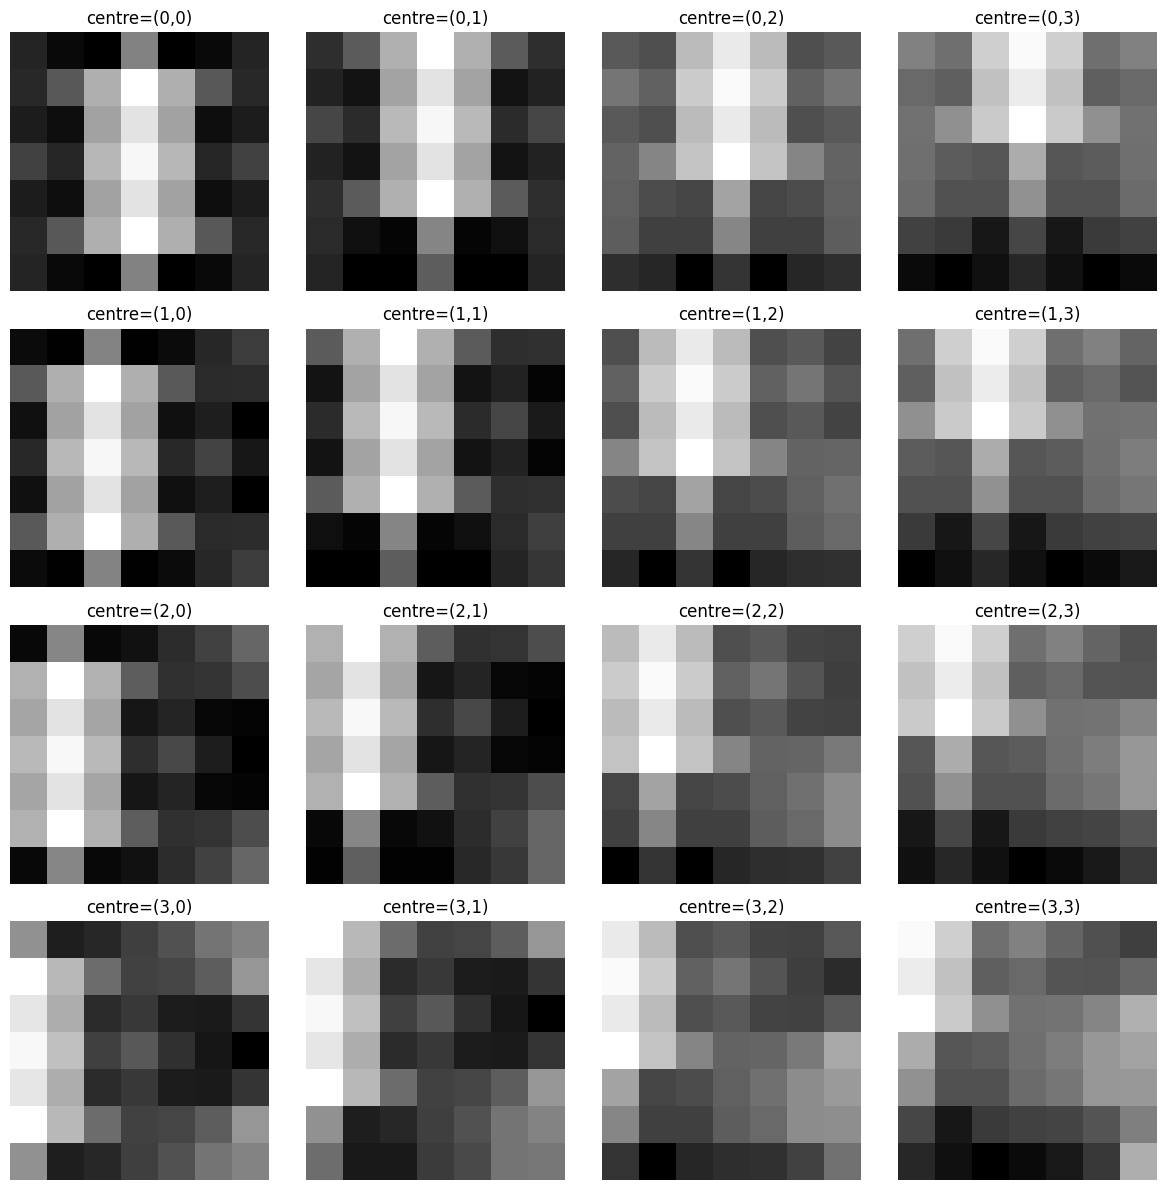

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# On affiche quelques patchs
fig, axes = plt.subplots(4, 4, figsize=(12,12))

pixel_coords = [
          (0, 0),(0, 1), (0, 2), (0, 3),
          (1, 0),(1, 1), (1, 2), (1, 3),
          (2, 0),(2, 1), (2, 2), (2, 3),
          (3, 0),(3, 1), (3, 2), (3, 3),
          ]  # centres (y, x)

for i, (y, x) in enumerate(pixel_coords):
    ax = axes[i // 4, i % 4]
    one_patch = matrxofpatch[y, x]       # one_patch est 2D: shape (3,3)
    ax.imshow(one_patch, cmap='gray')
    ax.set_title(f"centre=({y},{x})")
    ax.axis('off')

plt.tight_layout()
plt.show()

### __`Réduction de dimension avec PCA`__
Comme les algorithmes de type Non Local-means nécessitent le calcul d’un grand nombre de distances entre les patchs, il serait avantageux de réduire la dimension du patch tout en conservant le maximum d’informations possible.

In [10]:
# Dimension cible du patch
d = 25

#### __`Rappel`__
- une image naturelle contient beaucoup de motifs qui se répètent (textures, briques, feuillage, etc.),
- pas seulement localement mais partout dans l’image.
- pour débruiter un pixel $i$, NLM ne se limite pas à un petit voisinage local,
- il cherche, dans une zone plus large ou toute l’image, des patchs similaires au patch centré en $i$.
- la valeur débruitée de $i$ est une moyenne pondérée des valeurs d’autres pixels $j$, 
- où le poids est d’autant plus grand que le patch autour de $j$ ressemble à celui de $i$.

#### __`Réduction de dimension obtenue par (Analyse Composantes Principales)`__:
- projection des données sur un petit nombre de direction principales de la matrice de covariance. 
- réorganisation de la matrice de patchs en un tableau de dimension $|(w1*w1,n*n)|$ 
- `de sorte que chaque colonne |P(:,i)| soit un vecteur représentant un patch`. 

In [11]:
patch_matrix = lambda P,w,n : np.reshape(P,(((2*w+1)*(2*w+1)),(n*n)))

##### __`Un opérateur pour retirer la moyenne des patchs pour chaque patch`__ 
__`L’idée est de centrer chaque patch, comme fait avec les données avant une ACP`__
Si on précise en notation matricielle, avec $Q\in R^{d×N}$  : 
- $d=w_1^2$ le nombre de pixels par patch,
- $N = n * n$ le nombre de patchs,
- chaque colonne $Q(:,i)$ est un patch aplati.
__`Centrer chaque patch pour chaque colonne i :`__
   - on calcule sa moyenne scalaire $m_i =mean(Q(:,i))$, 
   - on construit un nouveau vecteur  $Q_{centered} (:,i)=Q(:,i)−m_i^1$, 
   - où 1 est un vecteur de 1 de taille d.

In [12]:
patch_centred = lambda patch_matrix :patch_matrix - np.mean(patch_matrix,axis=0, keepdims=True)
# matrice de covariance (d, d), normalisée par N−1, donne un estimateur non biaisé de la covariance. 
cov_matrix = lambda M: (M @ M.T) / (M.shape[1] - 1)

`Calculons la moyenne et la covariance du nuage de point représentant les patchs`.
 - $patch_{matrixReshp}(P)$ met tous les patchs dans une grande matrice 2D, puis 
 - $patch_{centrered}$ centre chaque patch comme on le fait avant une ACP sur les données et on
 - construit la matrice de covariance CovMatrix = ptch_mtrx_rshp_cntrd @ ptch_mtrx_rshp_cntrd

$C$ calcule une matrice $(w1*w1 × w1*w1)$ proportionnelle à la matrice de covariance des patchs
 -  on ne divise pas par $n*n$, car pour l’ACP ça ne change pas les vecteurs propres.

In [13]:
def compute_eighenValues(matrxofpatch,w,n):
    ptch_mtrx_rshp = patch_matrix(matrxofpatch,w,n)
    ptch_mtrx_rshp_cntrd = patch_centred(ptch_mtrx_rshp)
    cov_mat = cov_matrix(ptch_mtrx_rshp_cntrd)
    vals, vecs = np.linalg.eigh(cov_mat)   # vecs.shape = (49, 49)
    idx = np.argsort(vals)[::-1]
    D = vals[idx]
    V = vecs[:, idx] 
    return V, D                     

Extraire les vecteurs propres triés par amplitude décroissante

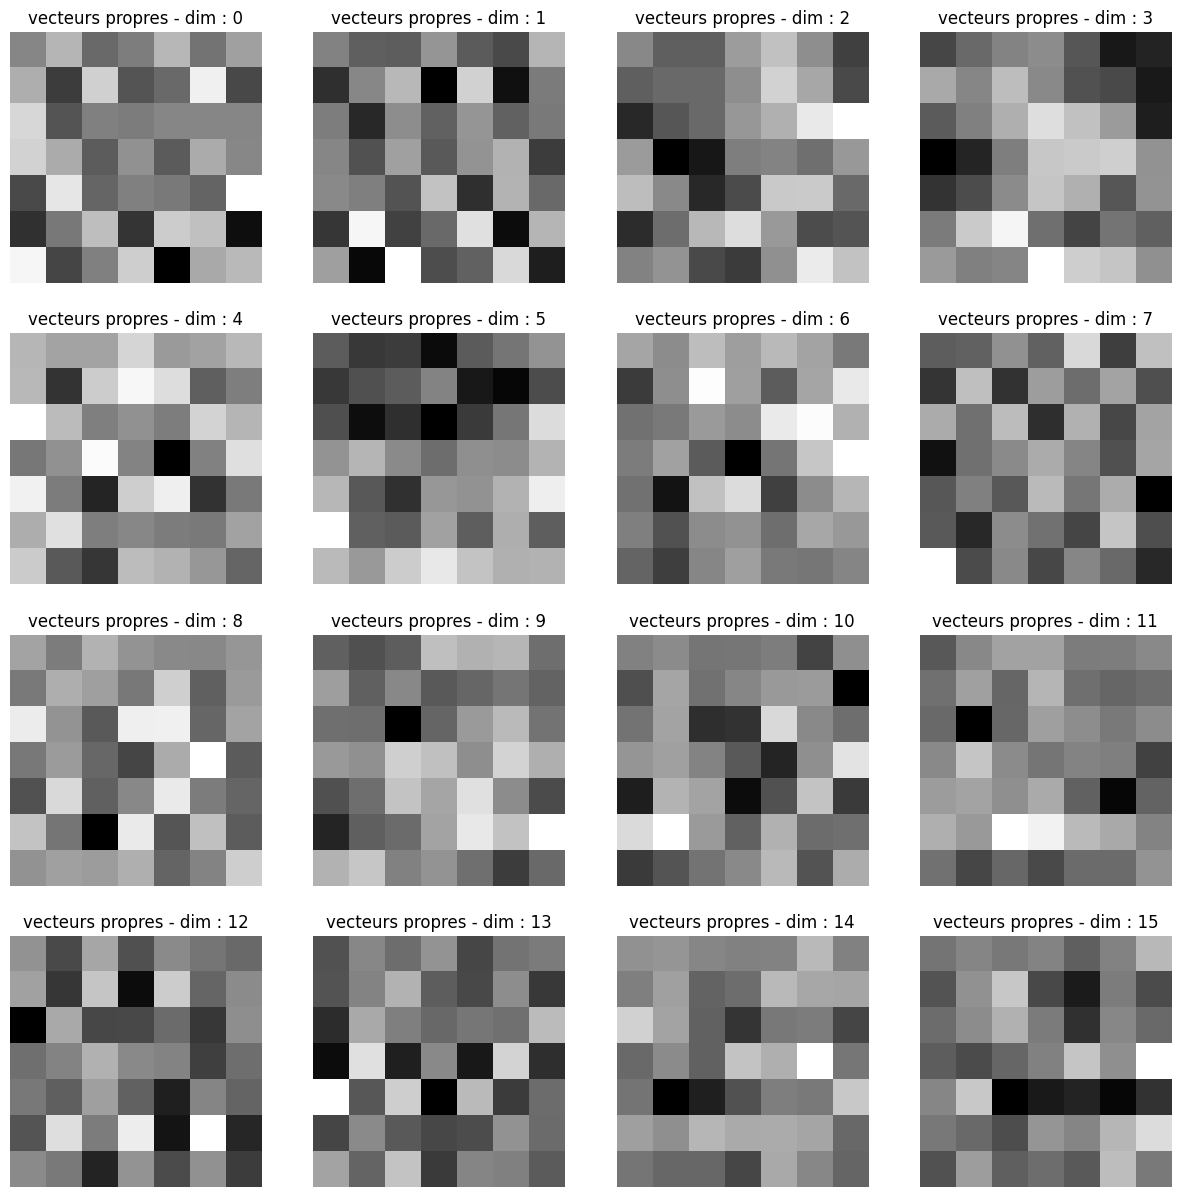

In [14]:
V, D = compute_eighenValues(matrxofpatch,w,n)

plt.figure(figsize=(15,15))
for i in range(16):
    mode = V[:, i].reshape((2*w+1), (2*w+1))        # 49 -> (7, 7), OK
    imageplot(mode, f'vecteurs propres - dim : {i}', [4, 4, i+1])

Chaque représentation est un vecteur propre de la matrice de covariance des patchs, remis en forme 7×7.
- la cov_matrix capture comment les intensités des pixels d’un patch 7×7 varient ensemble.
- ses vecteurs propres V[:, i] sont les directions principales de variation → des “patterns typiques” de patchs.
- V.shape = (49, 49) → chaque vecteur propre est bien un patch 7×7 aplati.
- La visualisation des 16 premiers mode = V[:, i].reshape(7, 7) donne des “atomes” de patchs, 
- ils ressemblent à des motifs de texture locaux (un peu bruités, car l’image est bruitée).

Afficher la décroissance de l’amplitude des valeurs propres.

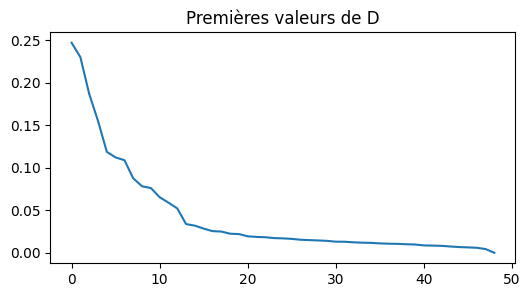

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(D)  # échelle log sur l'axe vertical
plt.title("Premières valeurs de D")
plt.show()

Le graphe montre les **valeurs propres** $D_i$ de ta matrice de covariance, triées décroissantes.
- En ACP chaque valeur propre $D_i$ = **variance expliquée** par la composante principale $i$ (donc par le vecteur propre $V[:, i]$. 
`Que dit ce graphe :`
1. **Les premières valeurs sont grandes**, puis ça chute vite :
    -  → Quelques composantes (premiers vecteurs propres) capturent l’essentiel de la variance des patchs. 
2. __Vers le rang 10 à 15__, les valeurs propres deviennent petites et décroissent linéairement :  
    - → au delà ces composantes apportent peu d’information, elles modélisent surtout du bruit. 
`Conséquence pour la` __`réduction de dimension :`__
- On peut choisir un $d$ (nombre de composantes gardées) :
  - soit au “coude” de la courbe (là où elle se casse, typiquement ≈ 10),  
  - soit en imposant un pourcentage de variance cumulée (par ex. 95 %). 
- Ensuite, on projette chaque patch sur les $d$ premiers vecteurs propres :  
  - avant : patch ∈ $\mathbb{R}^{49}$,  
  - après : descripteur ∈ $\mathbb{R}^{d}$, tout en conservant la majeure partie de l’information.

Ce graphe **visualise le nombre de composantes utiles** pour compresser les patchs conservant leur contenu significatif.

#### __`Opérateur de réduction de dimensionnalité des patchs`__
Chaque $H(i,j,:)$ est un descripteur de patch de dimension d.

`Projection ACP des patchs sur un sous-espace de dim=16 défini par les d premiers vecteurs propres`.
 __V_d = V[:, :d]__ 
- sélectionne les d premiers vecteurs propres (colonnes) de V, 
- la matrice $(w_1^², w_1^²)$ issue de eigh(cov_matrix). V_d a la shape $(w_1^², d)$.
__resh(P, w)__ 
- reshape P de $(n, n, w_1, w_1)$ vers $(w_1^², n^²)$ 
- chaque colonne est un patch vectorisé. 
- c'est la même chose que patch_matrix d'avant.
__remove_mean(M)__
- retourne un tuple (M_centré, moyenne) en soustrayant la moyenne sur axis=0 (par composante du patch).
- renvoie deux objets, d'où le [0] dans descriptor pour prendre uniquement la matrice centrée.
__V_d.T @ remove_mean(resh(P,w))[0]__
- projette les patchs centrés dans la base ACP

Chaque colonne du résultat est le code ACP de dimension d'un patch : $\underbrace{V_d^T}_{(d,\, w_1^2)} \cdot \underbrace{M_c}_{(w_1^2,\, n^2)} = \underbrace{\text{codes}}_{(d,\, n^2)}$
__iresh(M) reshape (d, n²) vers (d, n, n) puis transpose en (n, n, d) :__ 
- on récupère une image 2D où chaque pixel porte un vecteur de `d coefficients ACP`.

`Note :` arr.shape = (d0, d1, d2, ...). --> arr.shape = (axis=0, axis=1, axis=2, ...)

In [16]:
#resh   = lambda P,w: P.reshape((2*w+1)**2, -1)                    # (d_full, N) = (49, 16384)
iresh  = lambda M: M.reshape(d, n, n).transpose(1, 2, 0)          # (n, n, d)
remove_mean = lambda M: (M - M.mean(axis=0, keepdims=True), M.mean(axis=0, keepdims=True))
#descriptor = lambda P,V_d,w: iresh( V_d.T @ remove_mean(resh(P,w))[0])
def resh(P, w):
    n = P.shape[0]
    return P.reshape((2*w+1)**2, n*n)

def descriptor(P, V_d, w):
    R = resh(P, w)               # (d_full, n*n)
    R0, meanP = remove_mean(R)
    M = V_d.T @ R0               # (d, n*n)
    d, N = M.shape
    n = int(np.sqrt(N))
    return M.reshape(d, n, n).transpose(1, 2, 0)  # (n, n, d)

Afficher les principaux vecteurs propres, ils ressemblent à des modes de Fourier

V_d (49, 20), matrxofpatch : (128, 128, 7, 7) H : (128, 128, 20) 


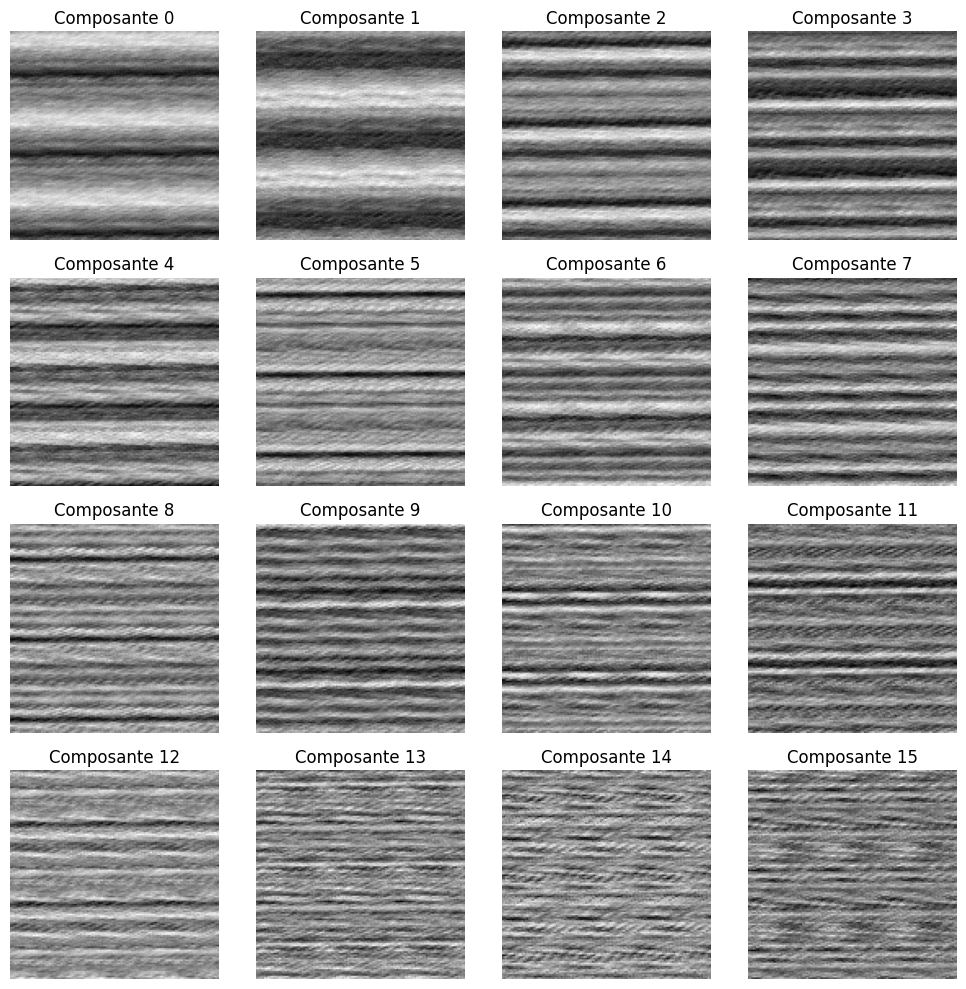

In [17]:
import numpy as np
import matplotlib.pyplot as plt

d = 20
V_d = V[:, :d]   # V est (w1*w1, w1*w1), V_d est (w1*w1, d)

H = descriptor(matrxofpatch,V_d,w)
print(f"V_d {V_d.shape}, matrxofpatch : {matrxofpatch.shape} H : {H.shape} ")

# On affiche quelques patchs
fig, axes = plt.subplots(4, 4, figsize=(10,10))

for k in range(16):
    ax = axes[k // 4, k % 4]       
    ax.imshow(H[:,:,k] , cmap='gray')
    ax.set_title(f"Composante {k}")
    ax.axis('off')

plt.tight_layout()
plt.show()


En PCA, les vecteurs propres d’un champ stationnaire gaussien sont très proches des **fonctions propres de la covariance**, qui, pour des processus invariants par translation, sont justement des **harmoniques de Fourier** (ondes planes). 
- chaque carte $H[:,:,k]$ est la “réponse” de la composante principale $k$ au motif de base (l’image de franges).  
- les données (patchs) sont essentiellement des **ondes sinusoïdales quasi périodiques**; 
- leur base de variance maximale va ressembler à des **motifs sinusoïdaux** de différentes fréquences / orientations.  

Donc ce que l'on observe :  
- `composantes basses (0–3)` : structures plus lisses, “basses fréquences” (grandes franges),  
- `composantes plus élevées` : franges plus serrées → “hautes fréquences”.

Ce nest pas dans le domaine de Fourier, on fait une PCA sur patchs 7×7 réels, pas une TF complexe globale **cela mime fortement des modes de Fourier locaux** adaptés à la texture de l'image.

## __`Définition de Filtre Non-local`__
Filtre non local est un terme générique pour désigner toute opération où l’on utilise de l’information provenant de régions éventuellement lointaines de l’image; cela peut inclure NLM, mais aussi d’autres variantes et algos patch‑based.
- NLM est un filtre non local, basé sur des moyennes de pixels dont les patchs sont similaires.
- Patch‑based (EWA, BM3D, inpainting non local, etc.).

Non-local-means applique à chaque pixel un noyau de moyenne adaptatif calculé sur la distance entre patchs
- on note $H_{i} \in \mathcal{R}^d$ descripteur ou patch au pixel $i$.
- opérateur de distance entre patch (au sens quadratique) $i$ et $j$ : $D_{i,j} = \frac{1}{w_1^2}||{H_i-H_j}||^2$
Opérateur de distance entre patch
$$D_{i,j} = \frac{1}{w_1^2}||{H_i-H_j}||^2 =\large \frac{\sum (H_i^k - H_j^k) }{w_1^2}$$

In [18]:
distance_fnl = lambda i,w,H: ((H - H[i[0], i[1], :])**2).sum(axis=2) / (2*w+1)**2

Le filtre non-local de débruitage de l'image $\tilde f$ comme : $\tilde f_i=\sum_j K_{i,j} f_j $ forme générale du filtre Non‑Local Means.
- $f_j$ : intensité (ou couleur) du pixel $j$ dans l’image bruitée.
- $\hat f_i$ : intensité débruitée au pixel i.
- $K_{i,j}$  : poids non local, qui mesure la similarité entre le voisinage (patch) $i$ et de $j$. 
Ces poids vérifient en général $K_{i,j} ≥ 0$ et $\sum_j K_{i,j} = 1$ où les poids de $K$ sont calculés tel que : 
- Normalisation pour obtenir $ K_{i,j} = \large \frac{ \tilde K_{i,j} }{ \sum_{j'} \tilde K_{i,j'} }$
- Définition des poids bruts (non normalisés) $K_{i,j} = \large  \exp({-\frac{D_{i,j}}{2\tau^2}})$
La largeur $\tau$ de la gaussienne est très importante et doit être adaptée au niveau de bruit.
- Calculer et normaliser le poids.


In [19]:
normalize = lambda K: K/ K.sum()
kernel_fnl = lambda i,w,tau,H: normalize(np.exp(-distance_fnl(i,w,H)/ (2*tau**2)))

Calculer un exemple de kernel typique pour une position pixel donnée $(x,y)$. 
Afficher la distance quadratique et le noyau.

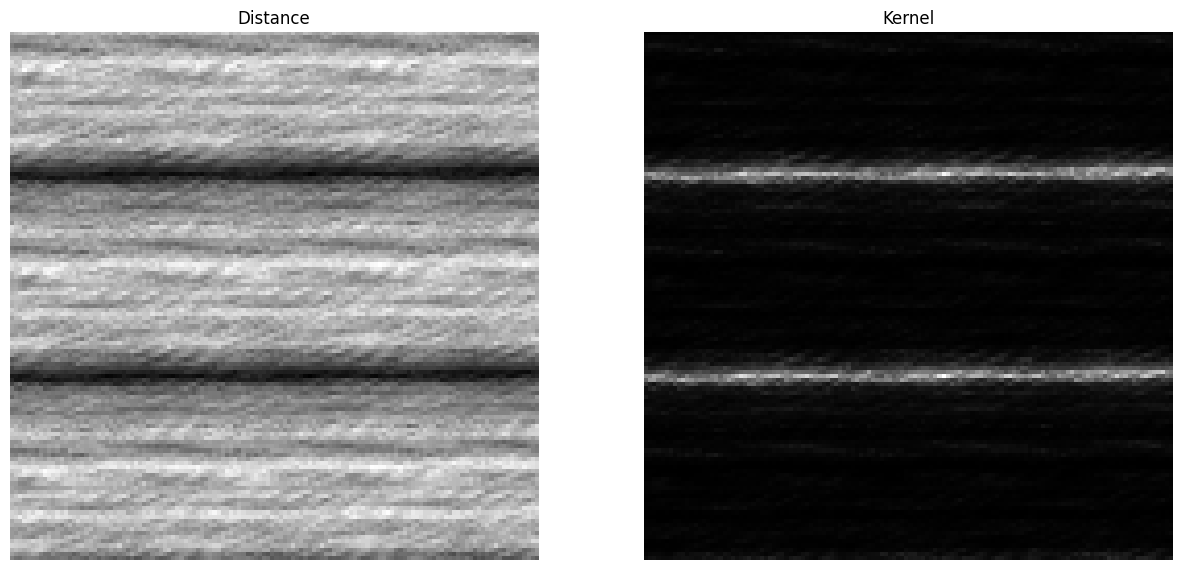

In [20]:
tau = .1
w = 3
i = [83,72]
D = distance_fnl(i,w,H)
K = kernel_fnl(i,w,tau,H)
# On affiche quelques patchs
plt.subplots(figsize=(15,15))
imageplot(D, 'Distance', [1, 2, 1])
imageplot(K, 'Kernel', [1, 2, 2])

Le résultat visuel est ce que l’on attend d’un NLM “patch‑PCA” une image de franges.

`distance(i)`  
- carte $D$ : pour chaque pixel $j$, la distance moyenne au carré entre descripteur PCA en $i$ et $j$.  
- sur la figure “Distance”, on voit les structures de franges : 
  - les zones textuellement similaires ont des distances proches, le bruit se voit comme du grain superposé.

`kernel(i, tau)`   
- transformation gaussienne des distances puis normalisation $K_{i,j}$.  
  - la figure “Kernel” montre que les poids sont forts (clairs) 
  - sur les positions dont les patchs sont similaires au patch central 
  - le long des mêmes franges et faibles ailleurs.  
  - La structure anisotrope du noyau (bandes) est logique 
  - la similarité se propage surtout le long des franges.

sur le choix $\tau = 0.05$  
- visuellement, le noyau n’est pas complètement concentré ni totalement uniforme 
- $\tau$ semble dans une plage raisonnable pour ce niveau de bruit
- on peut affiner en regardant le résultat final de débruitage.  
   - si on augmente $\tau$, le noyau deviendra plus “flou” (plus de zones gris clair, moyenne plus globale) ; 
   - si on diminue $\tau$, il se concentrera plus sur un petit ensemble de pixels.

donc :   
- visuellement, `Distance` et `Kernel` illustrent le comportement non local adapté à ta texture périodique.

### __`Localisation du filtre Non‑Local`__
`La localisation du filtre Non‑Local limite la portée non locale du filtre à une fenêtre finie autour de chaque pixel, au lieu de chercher des patchs similaires sur toute l’image.`

Théoriquement, NLM peut comparer le patch de $i$ avec **tous** les patchs $j$ de l’image : 
- la recherche est globale, donc vraiment “non locale”. 
- pour réduire le coût, on introduit un **paramètre de localité** (noté `q` ou “search window size”) 
- `q` définit une **fenêtre de recherche** autour de $i$ :  $ j \in \Omega_i = \{ j \;|\; \|j-i\|_\infty \le q \}$
- calculer les distances $D_{i,j}$ pour $j$ dans la fenêtre, on “localise le non‑local means” :
- le mécanisme reste non local, on fait une moyenne pondérée de pixels, 
- pas forcément voisins immédiats, déterminée par la similarité de patchs,  
- **la recherche de correspondances est limitée spatialement**, 
- ce qui rend l’algorithme plus rapide et en pratique “semi‑global” plutôt que totalement global.

Localiser le NLM revient à ajouter une **fenêtre de recherche autour de chaque pixel** pour restreindre le calcul des poids non locaux et accélérer le filtre. 

Avec NLM, on fixe $q$ pour limiter la distance dans le plan image entre les centres de patchs, la distance spatiale entre pixels $i$ et $j$, on ne compare que les patchs dont les centres sont dans une fenêtre $(2q+1)×(2q+1)$ autour de $i$.

En utilisant cette constante de localité, on calcule la distance entre les patchs uniquement à l’intérieur d’une fenêtre. Là encore, il faut faire attention aux conditions aux bords.

- opérateur de distance $i$ et $j$ : $D_{i,j} =\large \frac{1}{w_1^2}||{H_i-H_j}||^2$
- définition des poids bruts (non normalisés) $K_{i,j} = \exp^{({\Large -\frac{D_{i,j}}{2\tau^2}})}$ 

Mathématiquement, la fonction `selection(i,q,n)` représente l’ensemble des indices de pixels dans un voisinage carré de rayon $q$ autour du pixel $i$, tronqué aux bords de l’image.

Si $i = (i_1, i_2)$, $q \in \mathbb{N}$ et l’image est de taille $n \times n$, alors

$$
\text{selection}(i,q,n) \quad\longleftrightarrow\quad 
\mathcal{N}_q(i) = \Big\{ (j_1, j_2)\ \Big|\ 
\begin{aligned}
&\max(i_1 - q, 0) \le j_1 \le \min(i_1 + q, n-1),\\
&\max(i_2 - q, 0) \le j_2 \le \min(i_2 + q, n-1)
\end{aligned}
\Big\}.
$$

Autrement dit, $\mathcal{N}_q(i)$ est le voisinage local autour de $i$ dans lequel on autorise les pixels $j$ à contribuer à la moyenne non locale.

In [21]:
import numpy as np
# Chaque $H(i,j,:)$ est un descripteur de patch de dimension d.
selection     = lambda i,q,n     : (slice(max(i[0]-q,0), min(i[0]+q+1,n)),slice(max(i[1]-q,0), min(i[1]+q+1,n)))
distance_fnlm = lambda i,q,n,w,H : ((H[selection(i,q,n)[0], selection(i,q,n)[1],:] - H[i[0], i[1],:])**2).sum(axis=2)/(2*w+1)**2
normalize     = lambda K : K / K.sum()
kernel_fnlm   = lambda i,q,n,tau,w,H : normalize(np.exp(-distance_fnlm(i,q,n,w,H)/(2*tau**2)))

Calculer uniquement la distance et le kernel à l'intérieur d'une fenêtre.
- on ne calcule pas les distances $D_{i,j}$ et les poids $K_{i,j}$ pour tous les pixels $j$ de l’image.
- seulement pour les $j$ dans une fenêtre de recherche autour de $i$ (définie par la localité q).
Calculer un exemple typique de kernel pour une position de pixel $(x,y)$.

In [22]:
i = (85,90)
n = 128
q = 14
D = distance_fnlm(i,q,n,w,H)
tau = D.mean()
print(tau)
K = kernel_fnlm(i,q,n,tau,w,H)

0.06976736


Afficher la distance quadratique et le kernel.
- opérateur de distance $i$ et $j$ : $D_{i,j} = \frac{1}{w_1^2}||{H_i-H_j}||^2$
- kernel normalisé $K_{i,j} = \exp({\large -\frac{D_{i,j}}{2\tau^2}})$ 

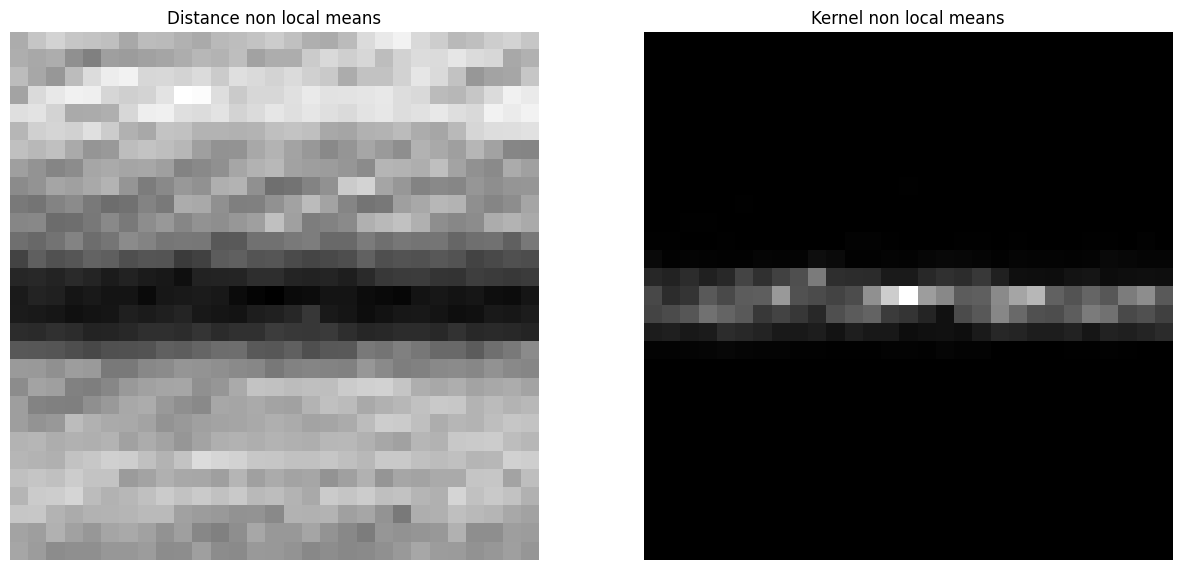

In [23]:
plt.subplots(figsize=(15,15))
imageplot(D, 'Distance non local means' ,[1, 2, 1])
imageplot(K, 'Kernel non local means', [1, 2, 2])

Ce résultat est **très bon** et cohérent avec ce qu'on attend du NLM sur l'image de Lena.

**Distance (gauche) :**
- Structure horizontale visible → les zones avec des intensités similaires (chapeau, fond) forment des bandes de faible distance
- Le grain superposé = le bruit gaussien
- La zone noire au centre = distance minimale (patch très similaire à lui-même)

**Kernel (droite) :**
- La **bande blanche horizontale** au milieu = poids forts concentrés sur les pixels similaires au patch central `i`
- Le reste est gris/sombre → poids faibles pour les zones dissimilaires
- La structure est **plus douce et étalée** qu'avant, ce qui signifie que `tau` est bien calibré

**Comparaison avec les résultats précédents :**

| Résultat précédent (franges) | Résultat actuel (Lena) |
|---|---|
| Kernel très concentré (points blancs) | Kernel plus étalé (bande large) |
| Structure anisotrope diagonale | Structure horizontale |
| Peu de pixels actifs | Plus de pixels actifs → meilleur débruitage |

**Conclusion :** Ce kernel est **mieux calibré** que les précédents. La bande blanche du kernel montre que le NLM va effectivement moyenner un ensemble significatif de pixels similaires, ce qui devrait donner un bon débruitage. C'est exactement le comportement attendu sur une image naturelle comme Lena.

La valeur Non-Local filtrée au pixel $(x,y)$ obtenu en moyennant les valeurs de $f$ de poids $K$.

In [24]:
# K : noyau sur la fenêtre locale
# f : image bruitée, shape (n, n)
# fenêtre de recherche autour de i sel est un tuple (sy, sx)
NLwindow   = lambda f, i, q, n: f[selection(i, q, n)[0], selection(i, q, n)[1]]
NLval = lambda f,i,q,n,tau,w,H: (kernel_fnlm(i,q,n,tau,w,H) * NLwindow(f, i, q, n)).sum()

Nous appliquons le filtrage pour chaque localisation de pixel pour exécuter l'algorithme NL-means.

In [25]:
# 2) moyenne non locale appliquée à l'image bruitée f
def NLmeans(f, q, tau, w, H):
    n = f.shape[0]
    out = np.zeros_like(f)
    for i1 in range(n):
        for i2 in range(n):
            out[i1, i2] = NLval(f,(i1,i2),q,n,tau,w,H)
    return out

Afficher le résultat pour une certaine valeur de $\tau$.

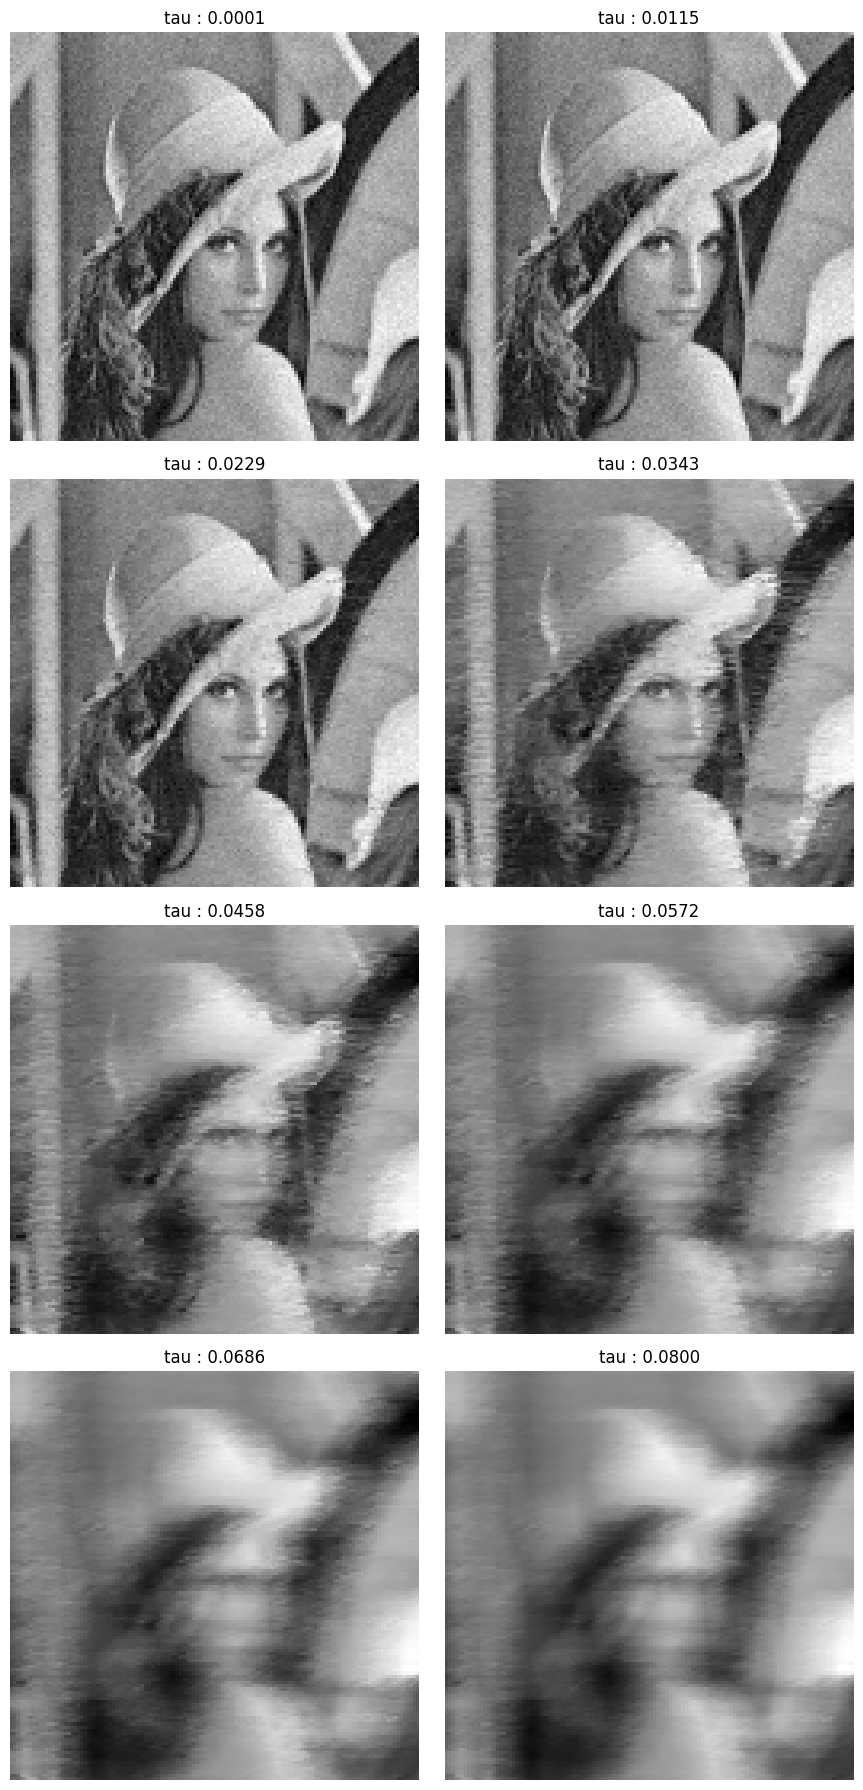

In [26]:
n   = 128
d   = 5
q   = 10

plt.figure(figsize=(9,18))
tau_list = np.linspace(0.0001, 0.08, 8)
for i,tau in enumerate(tau_list):
    imageplot(clamp(NLmeans(imgnoised,q,tau,w,H)),f"tau : {tau:.4f}", [4,2,i+1])
plt.tight_layout()
plt.show() 

### __`Exercice 1`__
Effectuer le débruitage pour plusieurs valeurs de $\tau$  afin de déterminer la valeur optimale qui minimise  $||{\tilde f - f_0}||$

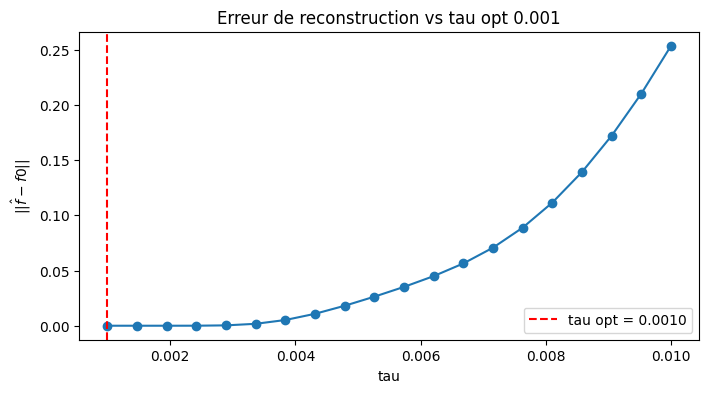

In [27]:
# f0 : image originale normalisée (sans bruit)
f0 = imgtrue.copy()
f = imgnoised.copy()
tau_list = np.linspace(0.001,0.01,20)
errors   = []

for tau in tau_list:
    f_tilde = NLmeans(f,q,tau,w,H)
    err = np.linalg.norm(f_tilde - f)
    errors.append(err)

# tau optimal
tau_opt = tau_list[np.argmin(errors)]

# affichage
plt.figure(figsize=(8,4))
plt.plot(tau_list, errors, marker='o')
plt.xlabel("tau")
plt.ylabel(r"$||\hat f - f0||$")
plt.title(f"Erreur de reconstruction vs tau opt {tau_opt}")
plt.axvline(tau_opt, color='r', linestyle='--', label=f"tau opt = {tau_opt:.4f}")
plt.legend()
plt.show()

Afficher l'image débruitée avec le $\tau$ optimal 

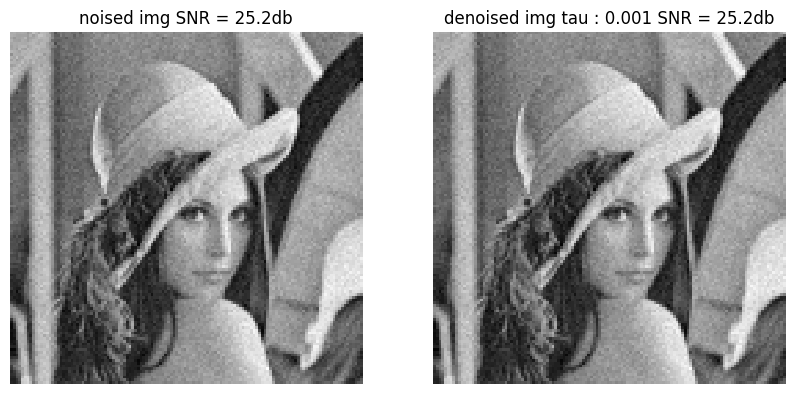

In [28]:
plt.figure(figsize=(10,18))
imageplot(f,f"noised img SNR = {snr(f0,f):.3g}db",[1,2,1])
f1 = NLmeans(f,q,tau_opt,w,H)
imageplot(f1,f"denoised img tau : {tau_opt:.3f} SNR = {snr(f0,f1):.3g}db",[1,2,2])

### __`Exercice 2`__
Explorer l'influence des paramètres $q$ et de $w$ sur le débruitage

In [29]:
# f0 : image originale normalisée
f_true   = imgtrue.copy()
f_nois   = imgnoised.copy()
f_rshp   = imgnoised_reshp.copy()
w_list   = np.linspace(10,30,10).astype(int)
q_list   = np.linspace(10,30,10).astype(int)
tau_list = np.linspace(0.001,0.01,10)  
dist_list= np.linspace(10,30,10).astype(int)

results = []

for w_ in w_list:
    X,Y = patch_coords_grid(n,w_)
    matrxofpatch = compute_reflect_grid(f_rshp,n,X,Y)
    for d_ in dist_list:
        V, D = compute_eighenValues(matrxofpatch,w_,n)
        V_d = V[:, :d] 
        H = descriptor(matrxofpatch,V_d,w_)
        for q_ in q_list:
            for tau in tau_list:
                f_tilde = NLmeans(f_nois,q_,tau,w_,H)
                err = np.linalg.norm(f_tilde - f_true)
                results.append({'tau': tau, 'q': q_, 'w': w_, 'dist':d_, 'err': err})

# meilleur jeu de paramètres
best = min(results, key=lambda x: x['err'])
print(f"\nMeilleur : w={best['w']}, q={best['q']}, tau={best['tau']:.4f} dist={best['dist']} → err={best['err']:.4f}")


Meilleur : w=16, q=14, tau=0.0050 dist=10 → err=3.6536


In [30]:
w = best['w'] # 27
dist= best['dist'] # 28
tau = best['tau'] # 0.008
q = best['q'] # 24

X,Y = patch_coords_grid(n,w)
matrxofpatch = compute_reflect_grid(f_rshp,n,X,Y)
V, D = compute_eighenValues(matrxofpatch,w,n)
V_d = V[:,:dist] 
H = descriptor(matrxofpatch,V_d, w)

f_rshp : (16384,) X : (128, 128, 33, 33) w : 16
matrxofpatch : (128, 128, 33, 33)


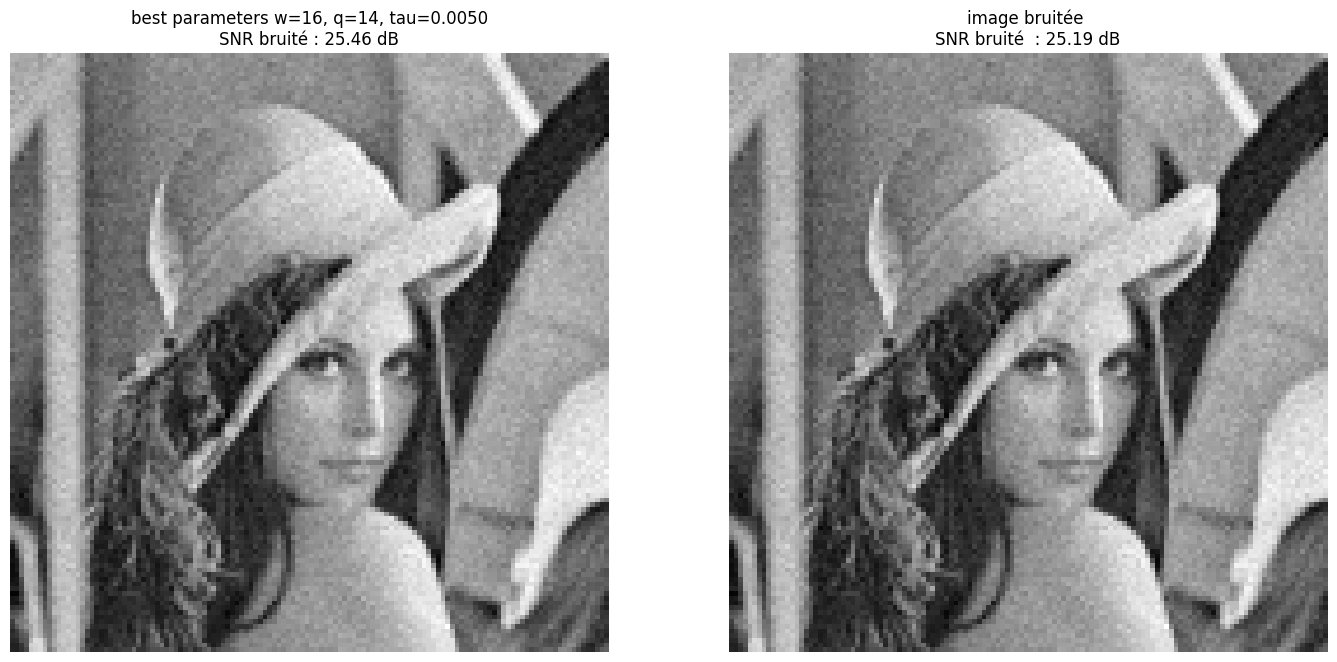

In [31]:
w = best['w']
dist= best['dist']
tau = best['tau']
q = best['q']
plt.figure(figsize=(17,12))
X,Y = patch_coords_grid(n,w)
print(f"f_rshp : {f_rshp.shape} X : {X.shape} w : {w}")
matrxofpatch = compute_reflect_grid(f_rshp,n,X,Y)
print(f"matrxofpatch : {matrxofpatch.shape}")
V, D = compute_eighenValues(matrxofpatch,w,n)

V_d = V[:,:dist] 
H = descriptor(matrxofpatch,V_d,w)
f_tilde = NLmeans(f_nois,q,tau,w,H)

imageplot(clamp(f_tilde),f"best parameters w={w}, q={q}, tau={tau:.4f}\nSNR bruité : {snr(f_true, f_tilde):.2f} dB",[1,2,1])
imageplot(clamp(f),f"image bruitée \nSNR bruité  : {snr(f_true, f_nois):.2f} dB",[1,2,2])

In [32]:
def psnr(f_ref, f_den):
    mse = np.mean((f_ref - f_den)**2)
    return 10 * np.log10(1.0 / mse)

print(f"SNR bruité   : {snr(f0, f):.2f} dB")
print(f"SNR débruité : {snr(f0, f_tilde):.2f} dB")

SNR bruité   : 25.19 dB
SNR débruité : 25.46 dB


Meilleur : w=5, d=15, q=7, tau=0.0050 → err=69.1456

Bibliography
------------
<html><a name="biblio"></a></html>


* [BuaCoMoA05] Buades, B. Coll, J.f Morel, [A review of image denoising algorithms, with a new one][1], SIAM Multiscale Modeling and Simulation, Vol 4 (2), pp: 490-530, 2005.

[1]:http://dx.doi.org/10.1137/040616024